In [10]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

sys.path.append(str(project_root))

In [36]:
import torch

from torch.utils.data import DataLoader

from tqdm import tqdm

import sqlite3

import json

import gzip

import pandas as pd

In [12]:
from src.data.tokenizer import MahjongTokenizer

from src.features.tensorization import Tensorizer

from src.data.dataset import MahjongDataset

from src.data.collator import MahjongCollator

from src.models.transformer_model import (
    MahjongTransformer
)

from src.training.metrics import (
    compute_topk_accuracy,
)

from src.utils.tile_decoder import (
    tile136_to_string,
)

from src.utils.action_decoder import (
    decode_action,
)

from src.analysis.ukeire import (
    evaluate_discards_ukeire,
)

from src.analysis.error_analysis import (
    categorize_mistake,
)

In [13]:
tokenizer = MahjongTokenizer()

tensorizer = Tensorizer()

collator = MahjongCollator()

In [14]:
val_dataset = MahjongDataset(

    db_path="../data/discard/strategic.db",

    limit=100000,
)

print(len(val_dataset))

100000


In [15]:
val_loader = DataLoader(

    val_dataset,

    batch_size=64,

    shuffle=False,

    collate_fn=collator.collate,

    num_workers=4,

    pin_memory=True,

    persistent_workers=True,
)

In [16]:
model = MahjongTransformer()

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [18]:
checkpoint = torch.load(

    "../checkpoints/strategic_100k/strategic_baseline.pt",

    map_location=device,
)

/home/julia/miniforge3/envs/riichi-ai/lib/python3.11/site-packages/torch/cuda/__init__.py:235: UserWarning: 
NVIDIA GeForce RTX 5060 Laptop GPU with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_89 sm_90 compute_90.
If you want to use the NVIDIA GeForce RTX 5060 Laptop GPU GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


In [19]:
model.load_state_dict(
    checkpoint["model_state_dict"]
)

<All keys matched successfully>

In [20]:
model.to(device)

model.eval()

print("Checkpoint loaded.")

Checkpoint loaded.


In [21]:
criterion = torch.nn.CrossEntropyLoss()

total_loss = 0

total_correct = 0

total_samples = 0

In [22]:
with torch.no_grad():

    for batch in tqdm(val_loader):

        batch = {

            k: v.to(device)
            if isinstance(v, torch.Tensor)
            else v

            for k, v in batch.items()
        }

        targets = batch["target"]

        logits_list = model(batch)

        batch_loss = 0

        for logits, target in zip(
            logits_list,
            targets,
        ):

            target = target.unsqueeze(0)

            logits = logits.unsqueeze(0)

            loss = criterion(
                logits,
                target,
            )

            batch_loss += loss.item()

            prediction = torch.argmax(
                logits,
                dim=1,
            )

            total_correct += (
                prediction == target
            ).sum().item()

            total_samples += 1

        total_loss += batch_loss

  0%|          | 0/1563 [00:00<?, ?it/s]/home/julia/miniforge3/envs/riichi-ai/lib/python3.11/site-packages/torch/nn/modules/transformer.py:508: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1739474893324/work/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(
100%|██████████| 1563/1563 [02:20<00:00, 11.16it/s]


In [23]:
val_loss = total_loss / len(val_loader)

val_accuracy = total_correct / total_samples

print(f"Validation Loss: {val_loss:.4f}")

print(f"Validation Accuracy: {val_accuracy:.4f}")

Validation Loss: 64.0993
Validation Accuracy: 0.6675


In [24]:
top3_correct = 0

top3_total = 0

with torch.no_grad():

    for batch in tqdm(val_loader):

        batch = {

            k: v.to(device)
            if isinstance(v, torch.Tensor)
            else v

            for k, v in batch.items()
        }

        targets = batch["target"]

        logits_list = model(batch)

        top3_correct += compute_topk_accuracy(

            logits_list,

            targets,

            k=3,
        )

        top3_total += len(targets)

top3 = top3_correct / top3_total

print(f"Top-3 Accuracy: {top3:.4f}")

100%|██████████| 1563/1563 [02:18<00:00, 11.31it/s]

Top-3 Accuracy: 0.0141


In [25]:
top5_correct = 0

top5_total = 0

with torch.no_grad():

    for batch in tqdm(val_loader):

        batch = {

            k: v.to(device)
            if isinstance(v, torch.Tensor)
            else v

            for k, v in batch.items()
        }

        targets = batch["target"]

        logits_list = model(batch)

        top5_correct += compute_topk_accuracy(

            logits_list,

            targets,

            k=5,
        )

        top5_total += len(targets)

top5 = top5_correct / top5_total

print(f"Top-5 Accuracy: {top5:.4f}")

100%|██████████| 1563/1563 [02:14<00:00, 11.61it/s]

Top-5 Accuracy: 0.0149


In [28]:
conn = sqlite3.connect(
    "../data/discard/strategic.db"
)

In [29]:
results = []

In [30]:
NUM_SAMPLES = 1000

In [34]:
for offset in tqdm(range(NUM_SAMPLES)):

    query = f"""
    SELECT Data
    FROM Discard
    LIMIT 1 OFFSET {offset}
    """

    row = conn.execute(
        query
    ).fetchone()

    decoded = json.loads(
        gzip.decompress(row[0])
    )

    canonical_state = {

    "round_wind":
        decoded["round_wind"],

    "num_honba":
        decoded["num_honba"],

    "num_riichi":
        decoded["num_riichi"],

    "player_wind":
        decoded["player_wind"],

    "position":
        decoded["position"],

    "remain_tiles":
        decoded["remain_tiles"],

    "dora_indicators":
        decoded["dora_indicators"],

    "hand_tiles":
        decoded["hand_tiles"],

    "players": {

        "0": decoded["0"],
        "1": decoded["1"],
        "2": decoded["2"],
        "3": decoded["3"],
    },

    "valid_actions":
        decoded["valid_actions"],

    "action_idx":
        decoded["action_idx"],
    }

    tokens = tokenizer.tokenize(
        canonical_state
    )

    tensor_dict = tensorizer.tensorize(
        tokens
    )

    batch = collator.collate(
        [tensor_dict]
    )

    batch = {

        k: v.to(device)
        if isinstance(v, torch.Tensor)
        else v

        for k, v in batch.items()
    }

    with torch.no_grad():

        logits = model(batch)[0]

    probabilities = torch.softmax(
        logits,
        dim=0,
    )

    prediction = torch.argmax(
        probabilities
    ).item()

    expert_action = decoded[
        "valid_actions"
    ][
        decoded["action_idx"]
    ]

    model_action = decoded[
        "valid_actions"
    ][prediction]

    if expert_action["type"] != 1:
        continue

    if model_action["type"] != 1:
        continue

    expert_tile = expert_action[
        "tiles"
    ][0]

    model_tile = model_action[
        "tiles"
    ][0]

    discard_eval = evaluate_discards_ukeire(
        canonical_state
    )

    discard_lookup = {}

    for r in discard_eval:

        discard_lookup[
            r["discard"]
        ] = r

    expert_metrics = discard_lookup[
        expert_tile
    ]

    model_metrics = discard_lookup[
        model_tile
    ]

    row_result = {

        "expert_tile":
            tile136_to_string(
                expert_tile
            ),

        "model_tile":
            tile136_to_string(
                model_tile
            ),

        "same_action":
            expert_tile == model_tile,

        "expert_shanten":
            expert_metrics["shanten"],

        "model_shanten":
            model_metrics["shanten"],

        "expert_ukeire":
            expert_metrics["ukeire"],

        "model_ukeire":
            model_metrics["ukeire"],

        "ukeire_difference":
            expert_metrics["ukeire"]
            -
            model_metrics["ukeire"],

        "model_prob":
            probabilities[
                prediction
            ].item(),
    }

    row_result["category"] = (
        categorize_mistake(
            row_result
        )
    )

    results.append(
        row_result
    )

100%|██████████| 1000/1000 [00:11<00:00, 85.51it/s]


In [37]:
results_df = pd.DataFrame(
    results
)

results_df.head()

,expert_tile,model_tile,same_action,expert_shanten,model_shanten,expert_ukeire,model_ukeire,ukeire_difference,model_prob,category
0,east,west,False,4,4,66,67,-1,0.534196,near_equivalent
1,red,west,False,4,4,71,72,-1,0.534368,near_equivalent
2,west,west,True,3,3,32,32,0,0.460348,exact_match
3,south,south,True,3,3,52,52,0,0.677493,exact_match
4,2m,2m,True,3,3,54,54,0,0.652961,exact_match


In [38]:
distribution = (

    results_df["category"]

    .value_counts(normalize=True)
)

distribution

category
exact_match        0.657
equivalent         0.120
catastrophic       0.073
near_equivalent    0.065
ukeire_loss        0.053
shanten_loss       0.032
Name: proportion, dtype: float64

In [39]:
results_df[
    "ukeire_difference"
].mean()

np.float64(0.087)

In [40]:
results_df[
    "same_action"
].mean()

np.float64(0.657)

In [41]:
worst = results_df[

    results_df["category"].isin([
        "catastrophic",
        "shanten_loss",
        "ukeire_loss",
    ])
]

worst = worst.sort_values(

    by=[
        "category",
        "ukeire_difference",
    ],

    ascending=[
        True,
        False,
    ],
)

worst.head(20)

,expert_tile,model_tile,same_action,expert_shanten,model_shanten,expert_ukeire,model_ukeire,ukeire_difference,model_prob,category
540,1p,7p,False,3,2,79,20,59,0.415568,catastrophic
987,8m,red,False,3,2,62,16,46,0.826099,catastrophic
848,7s,8m,False,3,2,62,17,45,0.350964,catastrophic
952,2p,8m,False,3,2,67,23,44,0.743713,catastrophic
228,7s,7m,False,3,2,57,18,39,0.630961,catastrophic
365,8s,red,False,3,2,59,21,38,0.875953,catastrophic
787,5s,2s,False,2,1,49,11,38,0.910476,catastrophic
929,3s,8m,False,1,0,39,2,37,0.293220,catastrophic
95,green,2p,False,3,2,60,25,35,0.547336,catastrophic
284,2m,red,False,4,3,45,10,35,0.423614,catastrophic


In [42]:
best = results_df[

    results_df["same_action"] == False
]

best = best.sort_values(

    by=[
        "model_shanten",
        "ukeire_difference",
    ],

    ascending=[
        True,
        True,
    ],
)

best.head(20)

,expert_tile,model_tile,same_action,expert_shanten,model_shanten,expert_ukeire,model_ukeire,ukeire_difference,model_prob,category
273,8p,5p,False,0,0,4,6,-2,0.496490,near_equivalent
769,3p,5p,False,0,0,3,5,-2,0.254371,near_equivalent
963,1s,east,False,0,0,1,3,-2,0.821678,near_equivalent
42,5p,7p,False,0,0,3,3,0,0.720034,equivalent
204,1m,7m,False,0,0,3,3,0,0.314177,equivalent
695,8p,west,False,0,0,3,3,0,0.475308,equivalent
773,5s,5s,False,0,0,2,2,0,0.308067,equivalent
862,8s,7s,False,0,0,3,3,0,0.270769,equivalent
971,6p,3s,False,0,0,3,3,0,0.667502,equivalent
972,2s,3s,False,0,0,3,3,0,0.384819,equivalent


In [43]:
high_confidence_mistakes = results_df[

    results_df["same_action"] == False
]

high_confidence_mistakes = high_confidence_mistakes.sort_values(

    by="model_prob",

    ascending=False,
)

high_confidence_mistakes.head(20)

,expert_tile,model_tile,same_action,expert_shanten,model_shanten,expert_ukeire,model_ukeire,ukeire_difference,model_prob,category
567,5s,9m,False,1,1,5,5,0,0.975558,equivalent
392,2m,2s,False,1,1,16,17,-1,0.940048,near_equivalent
549,green,1p,False,2,1,38,10,28,0.928367,catastrophic
80,7m,1s,False,3,3,23,42,-19,0.922128,catastrophic
804,red,7p,False,1,1,7,7,0,0.918800,equivalent
819,north,6m,False,2,2,30,14,16,0.912093,ukeire_loss
787,5s,2s,False,2,1,49,11,38,0.910476,catastrophic
385,white,east,False,2,2,31,31,0,0.905509,equivalent
668,white,2p,False,2,2,16,19,-3,0.901371,catastrophic
398,5s,1s,False,1,1,16,29,-13,0.896380,catastrophic


In [44]:
results_df["category"].value_counts()

category
exact_match        657
equivalent         120
catastrophic        73
near_equivalent     65
ukeire_loss         53
shanten_loss        32
Name: count, dtype: int64

In [45]:
results_df.to_csv(

    "../reports/strategic_validation_analysis_100k.csv",

    index=False,
)

print("Saved.")

Saved.


In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

In [47]:
sns.set_theme(style="whitegrid")

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(

    x=category_.index,

    y=category.values,
)

plt.ylabel("Proportion")

plt.xlabel("Category")

plt.title(
    "Strategic Error Distribution"
)

plt.xticks(rotation=15)

plt.show()

NameError: name 'category' is not defined

<Figure size 1000x600 with 0 Axes>

In [ ]:
plt.savefig(

    "../reports/figures/category_distribution_100k.png",

    dpi=300,

    bbox_inches="tight",
)

NameError: name 'plt' is not defined

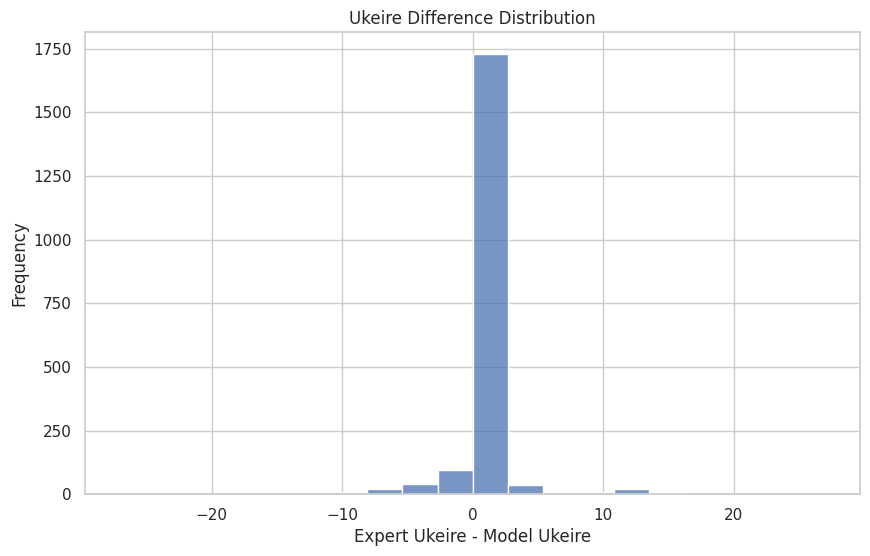

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(

    results_df["ukeire_difference"],

    bins=20,
)

plt.xlabel(
    "Expert Ukeire - Model Ukeire"
)

plt.ylabel("Frequency")

plt.title(
    "Ukeire Difference Distribution"
)

plt.show()

In [ ]:
plt.savefig(

    "../reports/figures/ukeire_distribution_100k.png",

    dpi=300,

    bbox_inches="tight",
)

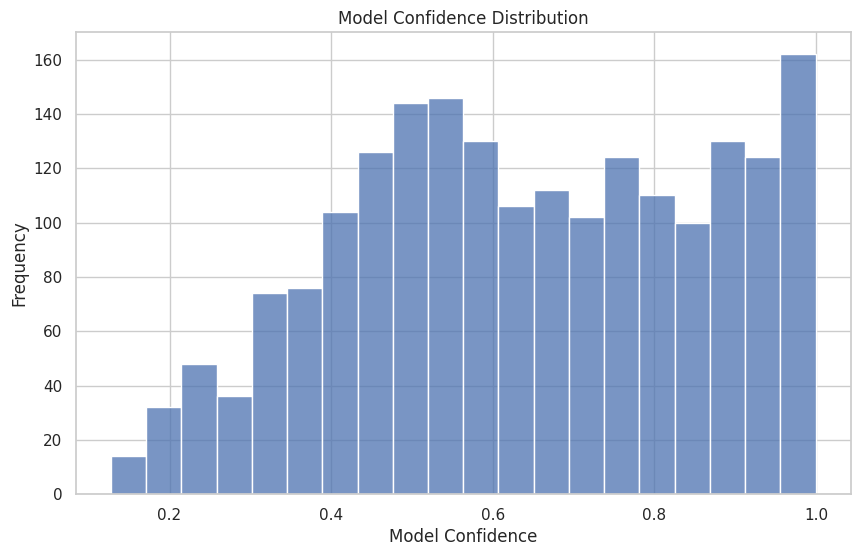

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(

    results_df["model_prob"],

    bins=20,
)

plt.xlabel(
    "Model Confidence"
)

plt.ylabel("Frequency")

plt.title(
    "Model Confidence Distribution"
)

plt.show()

In [ ]:
plt.savefig(

    "../reports/figures/confidence_distribution_100k.png",

    dpi=300,

    bbox_inches="tight",
)

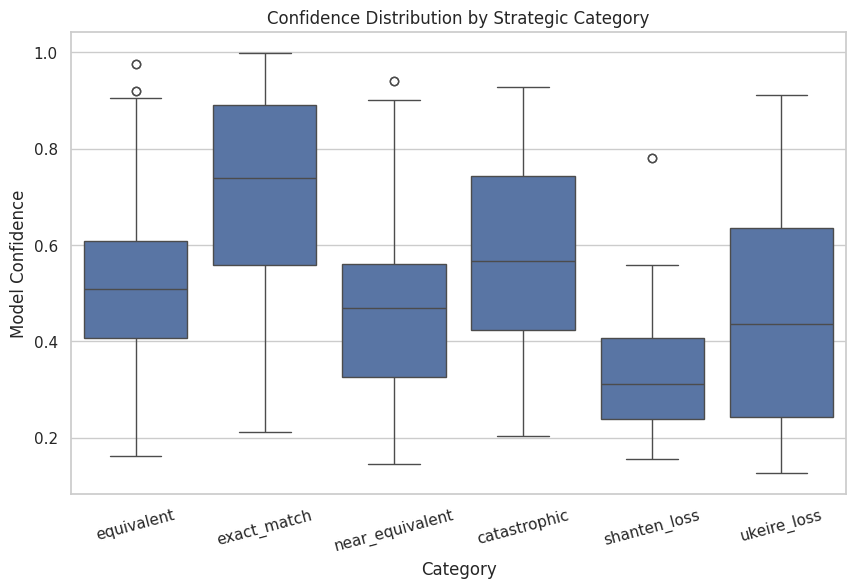

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(

    data=results_df,

    x="category",

    y="model_prob",
)

plt.xticks(rotation=15)

plt.xlabel("Category")

plt.ylabel("Model Confidence")

plt.title(
    "Confidence Distribution by Strategic Category"
)

plt.show()

In [ ]:
plt.savefig(

    "../reports/figures/category_confidence_distribution_100k.png",

    dpi=300,

    bbox_inches="tight",
)

In [ ]:
exact_accuracy = (
    results_df["same_action"]
    .mean()
)

strategic_accuracy = (

    results_df[
        "category"
    ]

    .isin([
        "exact_match",
        "equivalent",
        "near_equivalent",
    ])

    .mean()
)

print("Exact Accuracy:", exact_accuracy)

print("Strategic Accuracy:", strategic_accuracy)

Exact Accuracy: 0.657
Strategic Accuracy: 0.903


In [ ]:
comparison_df = pd.DataFrame({

    "metric": [
        "Exact Match",
        "Strategic Match",
    ],

    "value": [
        exact_accuracy,
        strategic_accuracy,
    ],
})

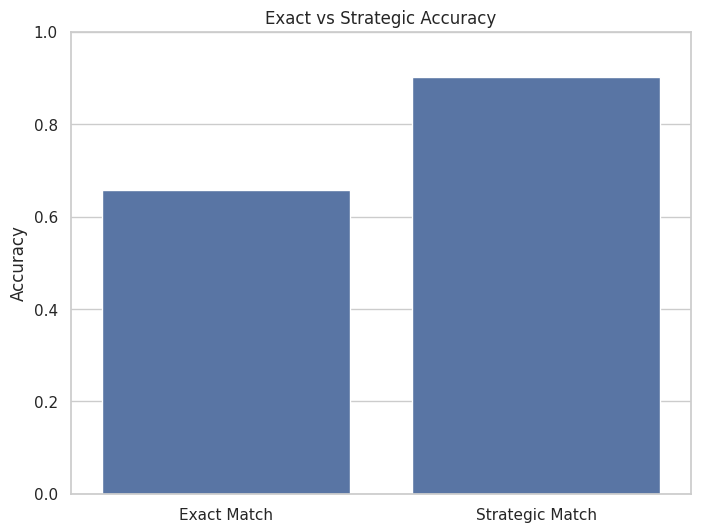

In [ ]:
plt.figure(figsize=(8, 6))

sns.barplot(

    data=comparison_df,

    x="metric",

    y="value",
)

plt.ylim(0, 1)

plt.ylabel("Accuracy")

plt.xlabel("")

plt.title(
    "Exact vs Strategic Accuracy"
)

plt.show()

In [ ]:
plt.savefig(

    "../reports/figures/accuracy_difference_100k.png",

    dpi=300,

    bbox_inches="tight",
)

<Figure size 640x480 with 0 Axes>